In [77]:
import pandas as pd
import keras 
import tensorflow
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
tensorflow.config.run_functions_eagerly(True)

In [78]:
df = pd.read_excel('amostras_inferenciadas.xlsx', engine='openpyxl', sheet_name='18_02_2020')

In [79]:
df.head(5)

,ID,AT,AC,OFERTA,VC,intervalo,UNI,"UNIx0,8 + ITBI","UNIx0,9 + ITBI",VP,...,ZH,PAV,UNI-PRA,CC,TIPO,END,BAIRRO,FONTE / IF,longitude,latitude
0,1,700.0,560,2100000.0,1.481028e+06,501-700,884.0,707.2,795.6,1,...,4,1,145.3827,1,GALPÃO,"AV VEREADOR DA COSTA RIOS, 1111",CENTRO,CIOFFI IMOVEIS,-45.930455,-22.245445
1,2,380.0,253,1100000.0,6.301932e+05,1001-1500,1236.0,988.8,1112.4,0,...,6,1,48.4600,0,RESIDENCIAL,"RUA PEDRO CALDAS REBELLO, 290",SANTO IVO,CIOFFI IMOVEIS,-45.923179,-22.219603
2,4,450.0,350,1900000.0,1.268652e+06,1001-1500,1403.0,1122.4,1262.7,0,...,6,1,672.0000,0,RESIDENCIAL,"RUA PROF MARIA FERNANDES CASCALLI, 105",FATIMA I,CIOFFI IMOVEIS,-45.915588,-22.221595
3,5,270.0,140,650000.0,3.677250e+05,701-1000,1045.0,836.0,940.5,0,...,5,1,116.2800,0,RESIDENCIAL,"RUA MARIO DE FREITAS CARDOSO, 20",POUSADA DOS CAMPOS III,CIOFFI IMOVEIS,-45.916247,-22.210899
4,6,300.0,0,200000.0,0.000000e+00,701-1000,667.0,533.6,600.3,0,...,5,1,62.0100,0,TERRENO,"RUA BENONE FERREIRA DA COSTA, AO LADO DO 205",NOSSA SENHORA DO PILAR II,CIOFFI IMOVEIS,-45.935582,-22.213639


In [80]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('unix0,9_+_itbi', 'target')
df['tipo'] = df['tipo'].str.replace(' ', '').str.lower()

In [81]:
df = pd.get_dummies(df, columns=['tipo'], dtype=int, drop_first=True)
df.columns

Index(['id', 'at', 'ac', 'oferta', 'vc', 'intervalo', 'uni', 'unix0,8_+_itbi',
       'target', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7',
       'z8', 'z9', 'itbi/of', 'zh', 'pav', 'uni-pra', 'cc', 'end', 'bairro',
       'fonte_/_if', 'longitude', 'latitude', 'tipo_casa', 'tipo_comercial',
       'tipo_galpão', 'tipo_predio', 'tipo_residencial', 'tipo_terreno'],
      dtype='object')

In [82]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('unix0,9_+_itbi', 'target').str.replace('ã', 'a')
df = df[['at', 'ac', 'target', 'vp', 'vs', 'ov', 'z1', 'z2', 'z3', 'z4',
         'z5', 'z6', 'z7', 'z8', 'z9', 'pav', 'cc', 'longitude', 'latitude',
       'tipo_casa', 'tipo_comercial',  'tipo_galpao', 'tipo_predio',
        'tipo_residencial', 'tipo_terreno']]
#rename cc to corredor_comercial
df = df.rename(columns={'cc': 'corredor_comercial', 'vp': 'via_principal', 'vs': 'via_secundaria', 'ov': 'outros_vias'})


In [83]:
# transforma pav 2 em 1 
df['pav'].loc[df['pav'] == 2] = 1

# converte lat e long para utm
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs='EPSG:4326')
gdf = gdf.to_crs(epsg=31983)  # SIR
df['x'] = gdf.geometry.x
df['y'] = gdf.geometry.y
df = df.drop(columns=['longitude', 'latitude'])

/tmp/ipykernel_1699/2086759106.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pav'].loc[df['pav'] == 2] = 1
/tmp/ipykernel_1699/2086759106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [84]:
kml_path = "zoneamento.kml"

gdf_kml = gpd.read_file(kml_path, driver='KML')

print(gdf_kml.head())


  Name Description                                           geometry
0                   MULTILINESTRING Z ((-45.9722 -22.24319 0, -45....


/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'zoneamento.kml': 'dissolved' (default), 'puparetificadissolvido', 'zepam1of', 'zep', 'zeep', 'zoneamentodissolvido'. Specify layer parameter to avoid this warning.
  result = read_func(


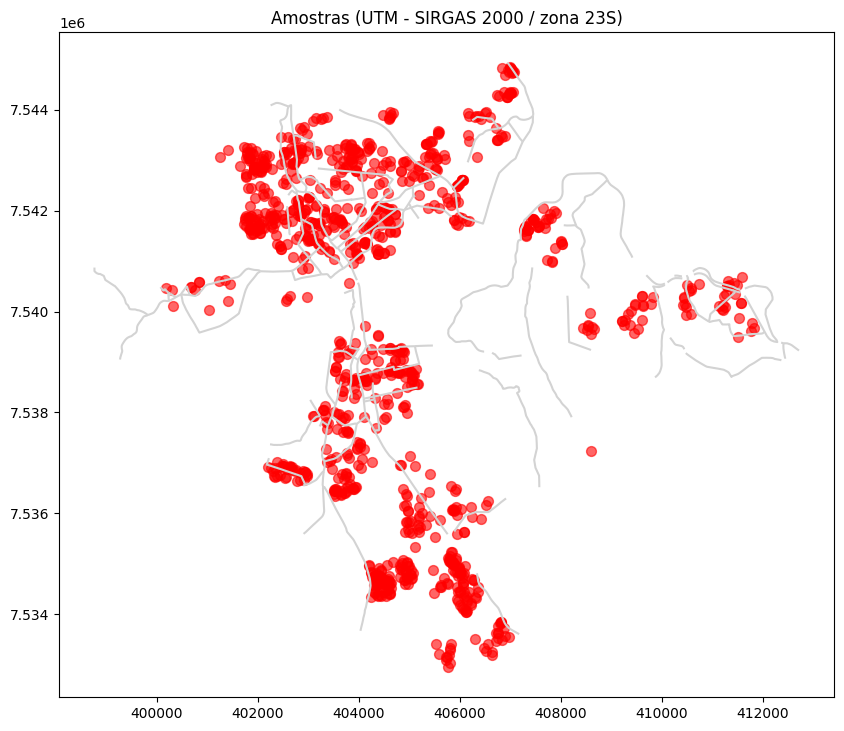

In [85]:
geometry = [Point(x, y) for x, y in zip(df['x'], df['y'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:31983")  # usa o mesmo CRS do SIRGAS UTM

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_kml.to_crs(epsg=31983).plot(ax=ax, color='lightgrey', edgecolor='black')  
gdf_points.plot(ax=ax, color='red', markersize=50, alpha=0.6)

plt.title("Amostras (UTM - SIRGAS 2000 / zona 23S)")
plt.show()

In [86]:
#find value that contains '-'
df[df.isin(['-']).any(axis=1)]

,at,ac,target,via_principal,via_secundaria,outros_vias,z1,z2,z3,z4,...,pav,corredor_comercial,tipo_casa,tipo_comercial,tipo_galpao,tipo_predio,tipo_residencial,tipo_terreno,x,y
31,1008.0,200,198.000000,0,0,1,0,0,0,0,...,-,0,0,0,0,0,1,0,408602.619818,7.537235e+06
107,627.0,0,186.300000,0,1,0,0,1,0,0,...,-,0,0,0,0,0,0,1,406302.262338,7.533502e+06
131,600.0,0,202.500000,0,0,1,0,1,0,0,...,-,0,0,0,0,0,0,1,405768.583724,7.532956e+06
132,600.0,0,180.000000,0,0,1,0,1,0,0,...,-,0,0,0,0,0,0,1,405726.571462,7.533163e+06
479,240.0,-,300.000000,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,1,408512.155746,7.539639e+06
482,1500.0,-,147.000000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409607.527057,7.540317e+06
483,800.0,-,281.250000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409624.157716,7.540109e+06
487,700.0,-,141.428571,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409333.040653,7.539954e+06
488,800.0,-,337.500000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,409384.917407,7.540012e+06
492,200.0,-,292.500000,0,0,1,0,1,0,0,...,1,0,0,0,0,0,0,1,405908.494981,7.534833e+06


In [87]:
#replace values that have "-" with null
df.replace("-", pd.NA, inplace=True)
df.dropna(inplace=True)
df['pav'] = df['pav'].astype(int)
df.loc[df['pav'] == 2, 'pav'] = 1

In [88]:
df.columns

Index(['at', 'ac', 'target', 'via_principal', 'via_secundaria', 'outros_vias',
       'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'pav',
       'corredor_comercial', 'tipo_casa', 'tipo_comercial', 'tipo_galpao',
       'tipo_predio', 'tipo_residencial', 'tipo_terreno', 'x', 'y'],
      dtype='object')

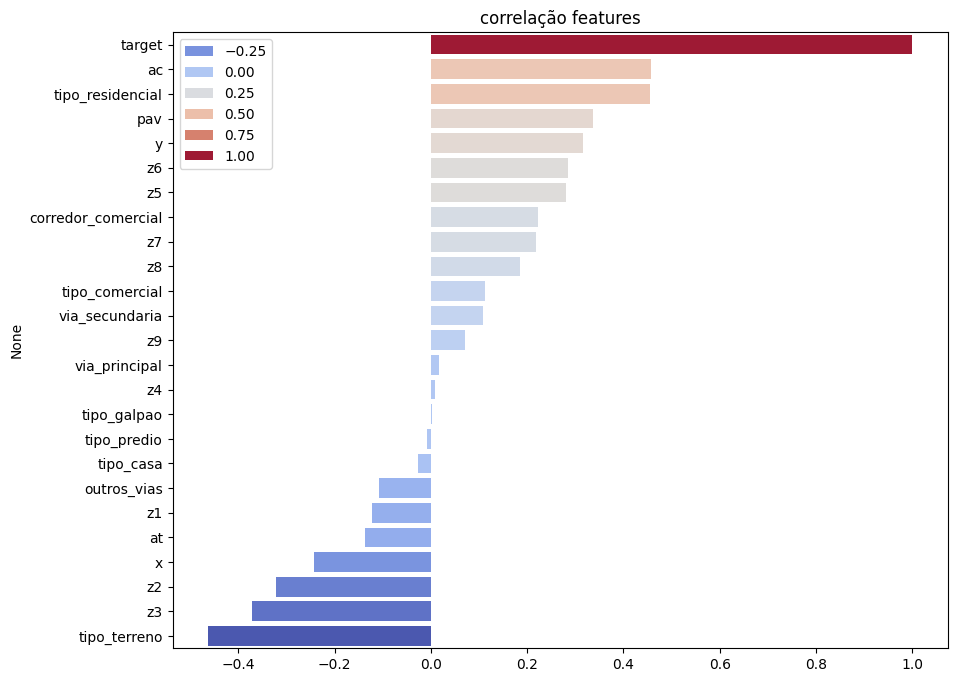

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_target = df.corr(method='spearman')['target'].sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.values, palette='coolwarm')
plt.title("correlação features")
plt.show()

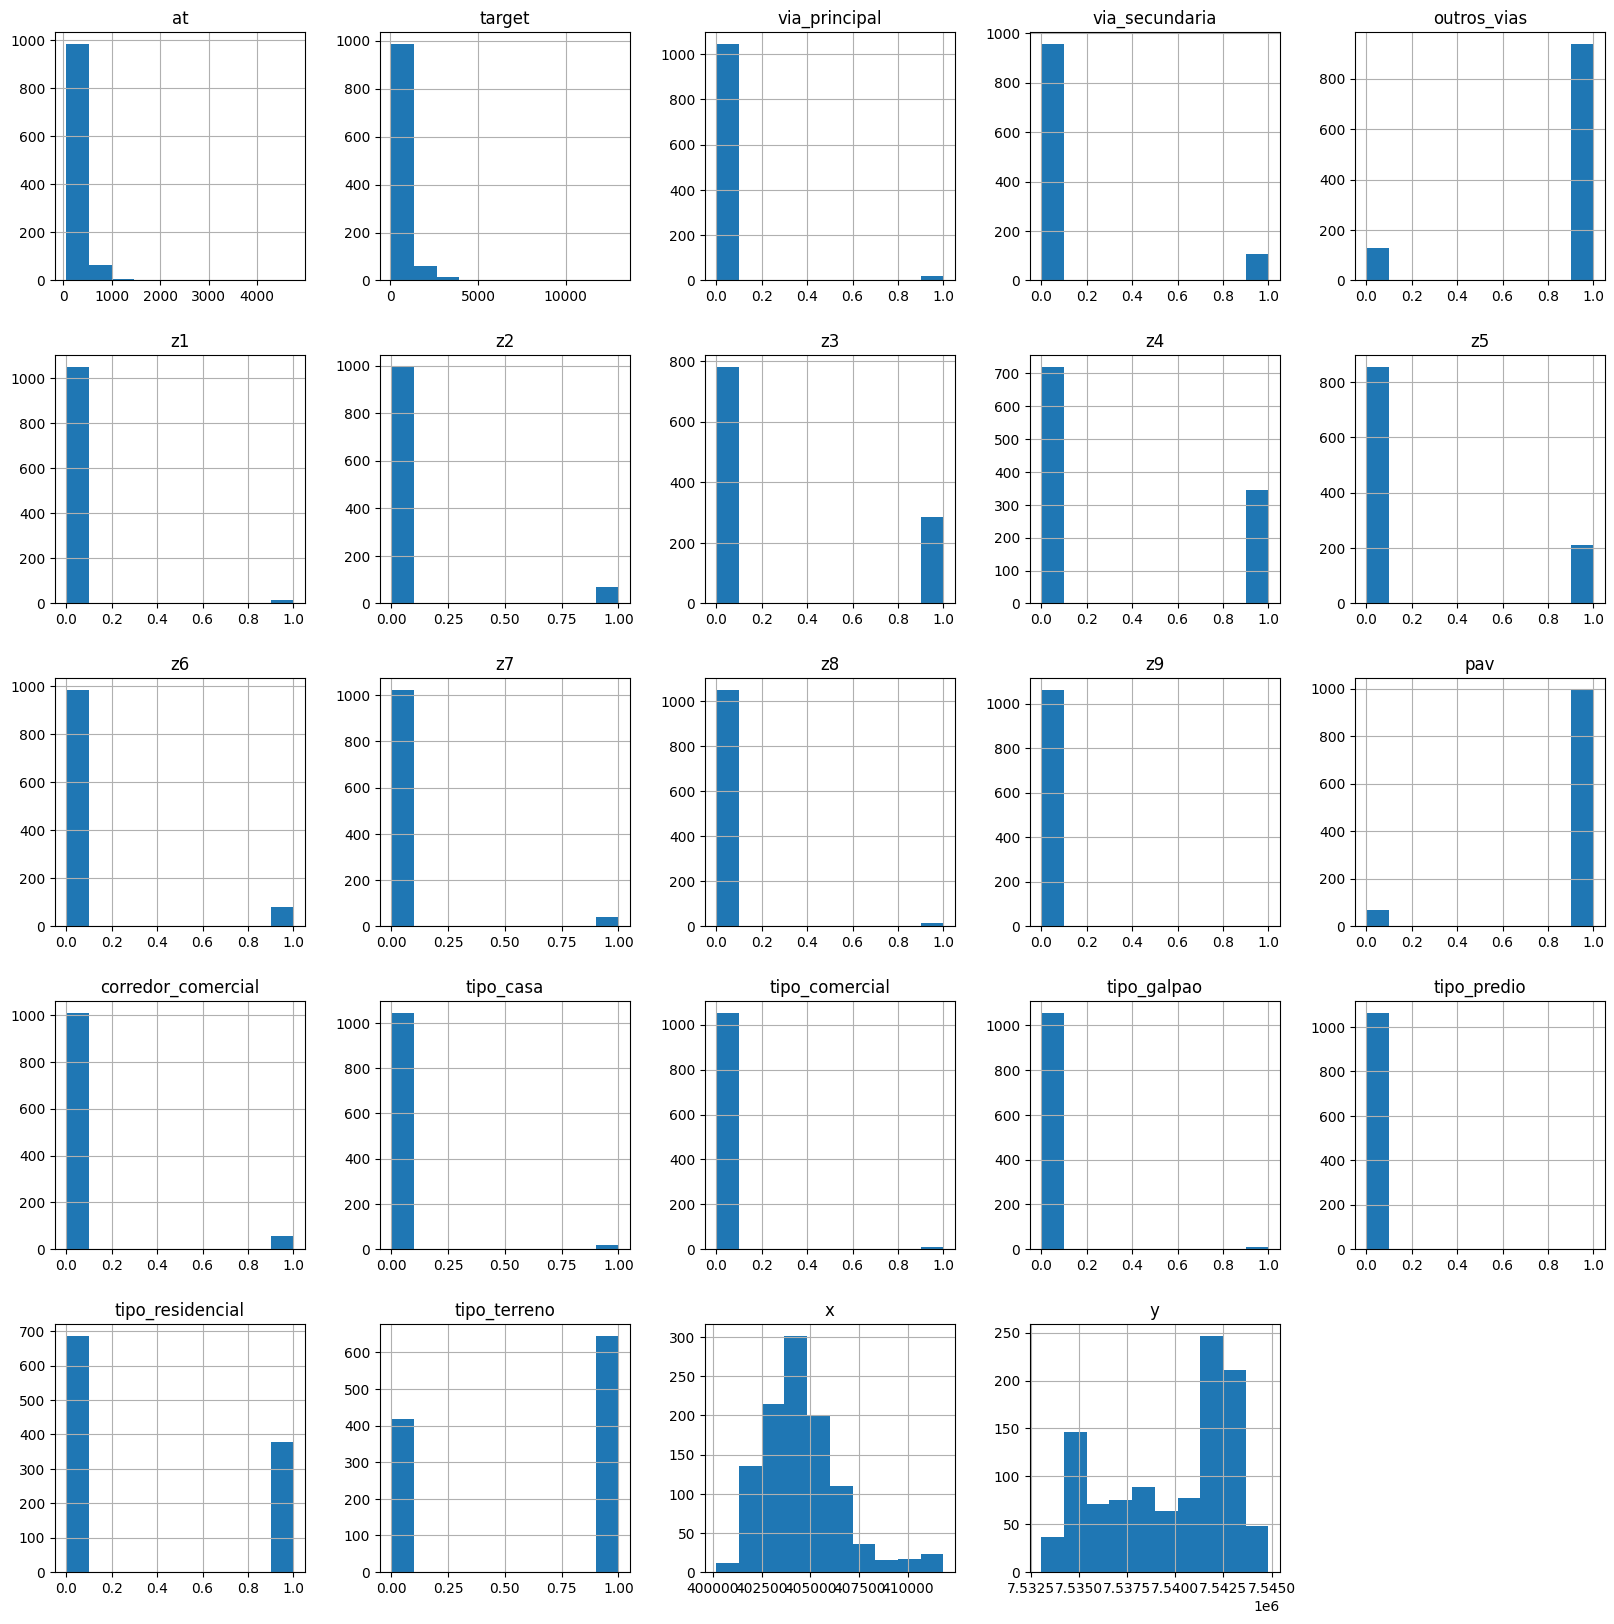

In [90]:
# plot histogram of each feature with a redline of the curve
df.hist(figsize=(20,20))
plt.show()

In [91]:
#normalize with log
log_df = df.copy()
log_df[log_df.columns] = log_df[log_df.columns].astype(float).apply(lambda x: np.log10(x + 1))

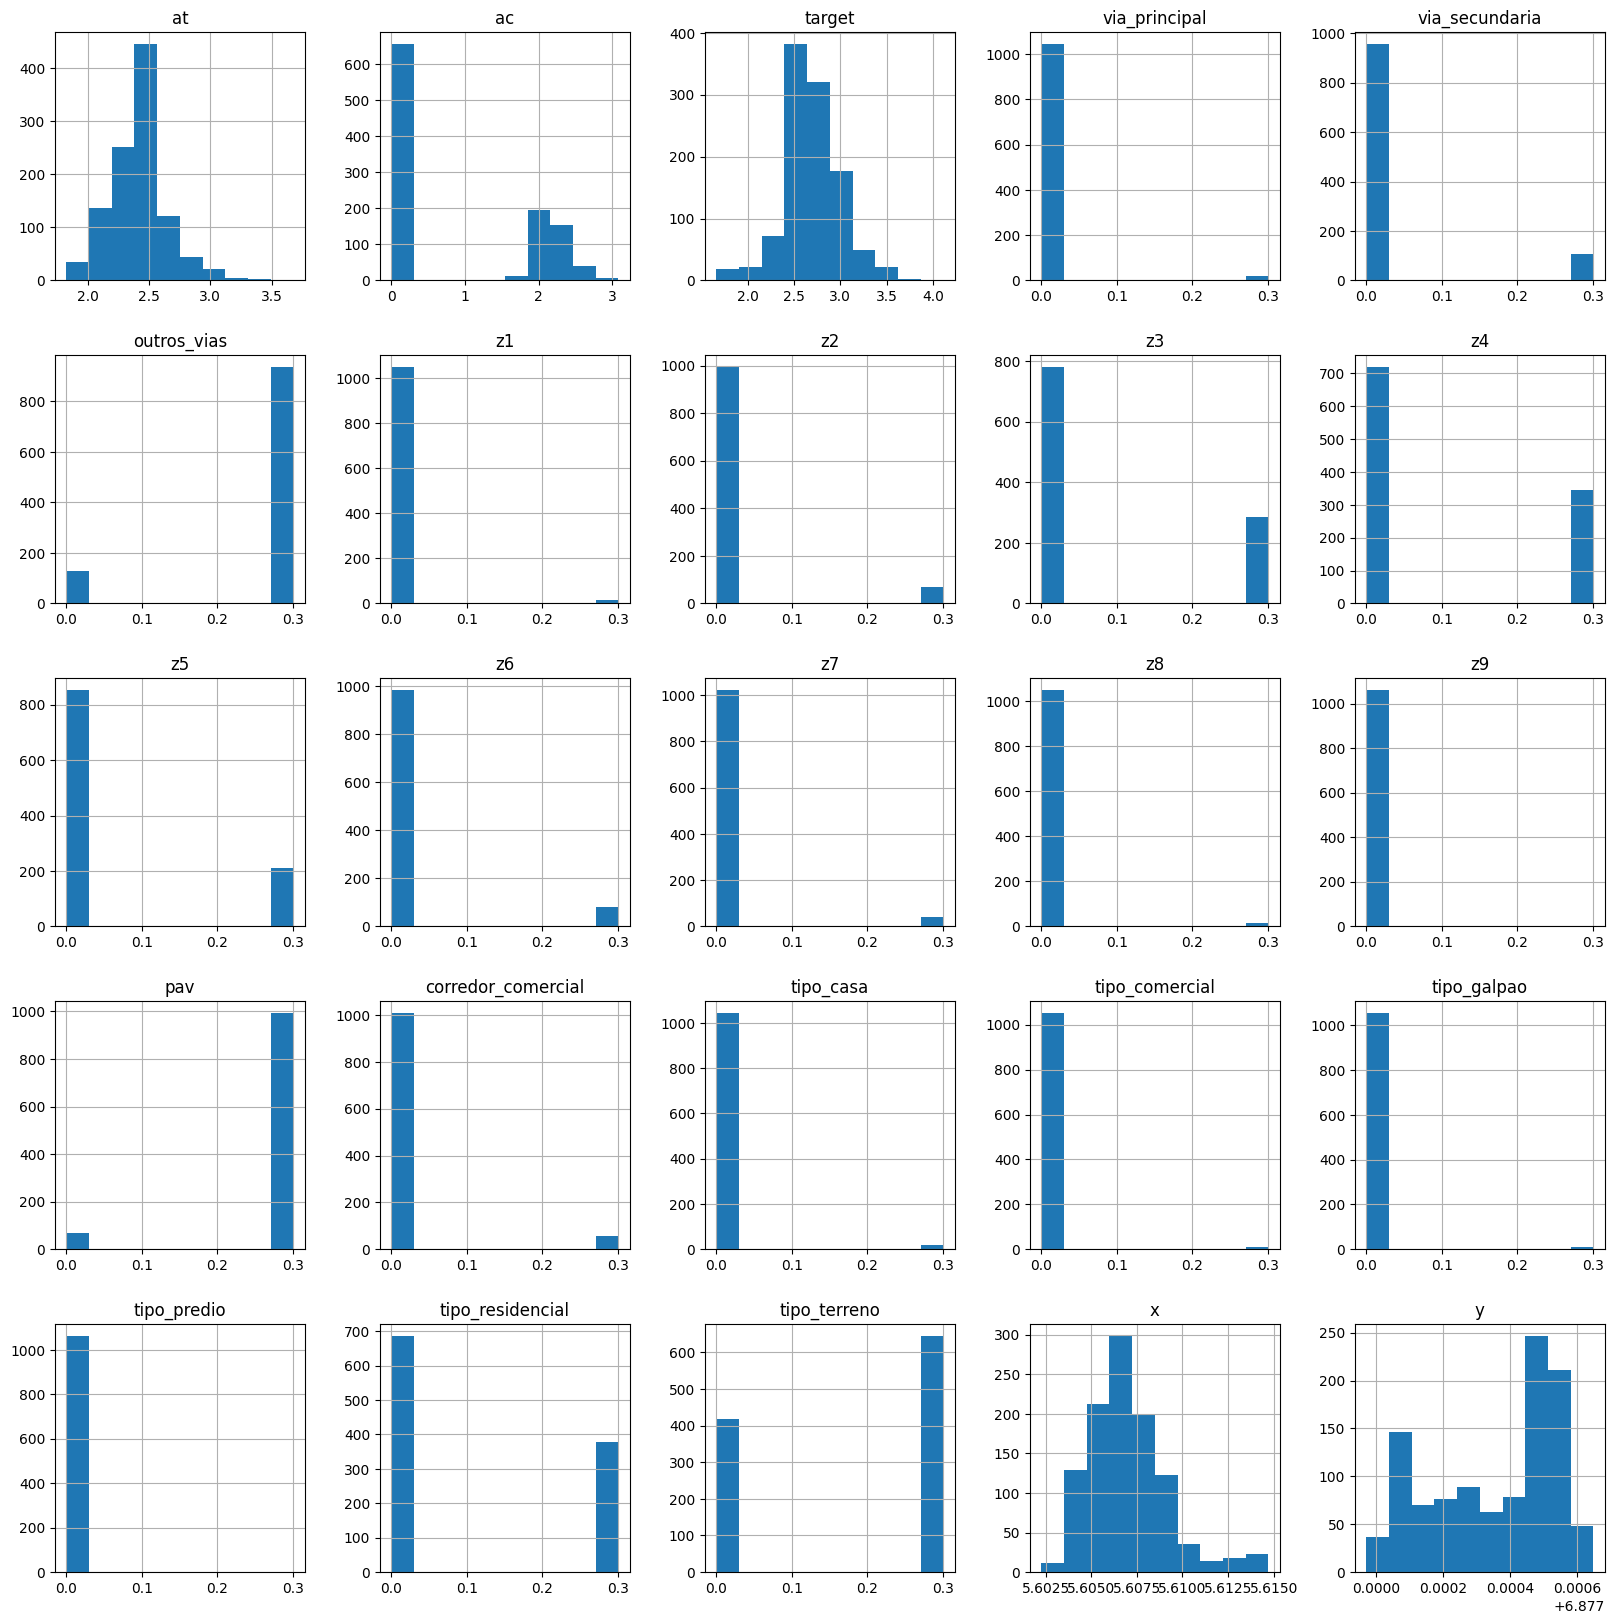

In [92]:
log_df.hist(figsize=(20,20))
plt.show()

## funções

In [93]:
def plot_regression_diagnostics(y_val, y_pred, X_val=None):
    df_result = pd.DataFrame({
        'Y': y_val,
        'Y_est': y_pred
    })
    df_result['r'] = df_result['Y'] - df_result['Y_est']
    df_result['rabs'] = df_result['r'].abs()

    r_mean = df_result['r'].mean()
    r_std = df_result['r'].std()
    r2 = r2_score(df_result['Y'], df_result['Y_est'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # --- 1. Y vs Y_est ---
    sns.scatterplot(data=df_result, x='Y', y='Y_est', ax=axes[0], color='green')
    axes[0].plot([df_result.Y.min(), df_result.Y.max()],
                 [df_result.Y.min(), df_result.Y.max()],
                 color='red', linestyle='--')
    axes[0].set_title(f'Y vs Y_est (R²={100*r2:.1f}%)')

    # --- 2. Resíduos vs Y ---
    sns.scatterplot(data=df_result, x='Y', y='r', ax=axes[1], color='orange')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title("Resíduos vs Y")

    # --- 3. Resíduos vs Y_est ---
    sns.scatterplot(data=df_result, x='Y_est', y='r', ax=axes[2], color='blue')
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title("Resíduos vs Y_est")

    # --- 4. Distribuição dos resíduos ---
    sns.histplot(df_result['r'], kde=True, bins=30, ax=axes[3], color='purple')
    axes[3].set_title(f"Distribuição dos resíduos\nMédia={r_mean:.2f}, Desv={r_std:.2f}")

    # --- 5. QQ-plot dos resíduos ---
    sm.qqplot(df_result['r'], line='45', fit=True, ax=axes[4])
    axes[4].set_title("QQ-plot dos resíduos")

    # --- 6. Opcional: Resíduos vs 1ª feature ---
    if X_val is not None:
        if isinstance(X_val, pd.DataFrame):
            feature_name = X_val.columns[0]
            sns.scatterplot(x=X_val.iloc[:,0], y=df_result['r'], ax=axes[5], color='brown')
            axes[5].axhline(0, color='red', linestyle='--')
            axes[5].set_title(f"Resíduos vs {feature_name}")
        else:
            axes[5].axis("off")
    else:
        axes[5].axis("off")

    plt.tight_layout()
    plt.show()

In [94]:
def linear_model(X, y, random_seed, callbacks, adam_initial_lr, adam_lr_decay):
    keras.utils.set_random_seed(random_seed)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    grid_results = []
    best_val_loss = float('inf')

    activations = ["linear"]
    for act in activations:
        print(f"\n=== Ativação: {act} ===")
        fold = 1
        fold_results = []

        for train_index, val_index in kf.split(X):
            print("Treinamento fold", fold)
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            optimizer = keras.optimizers.Adam(
                learning_rate=adam_initial_lr,
                decay=adam_lr_decay,   
            )

            model = keras.Sequential()
            model.add(keras.layers.InputLayer(input_shape=(X.shape[1],)))
            model.add(keras.layers.Dense(1, activation='linear'))

            model.compile(
                optimizer=optimizer,
                loss="mean_squared_error",
                metrics=["mse"]
            )

            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                validation_split=0.2,
                epochs=500,
                verbose=0,
                callbacks=callbacks
            )

            score = model.evaluate(X_val, y_val, verbose=0)
            print(f"[{act}] Fold {fold} - Val Loss: {score[0]:.4f}, Val MSE: {score[1]:.4f}")

            # Check if this is a new best model
            if score[0] < best_val_loss:
                best_val_loss = score[0]
                print(f"*** NOVO MELHOR MODELO! Activation: {act}, Fold: {fold}, Val Loss: {score[0]:.4f} ***")

            results = {
                'activation': act,
                'fold': fold,
                'val_loss': score[0],
                'val_mse': score[1],
                'model': model,
                'history': history
            }
            fold_results.append(results)
            grid_results.append(results)

            fold += 1

        # média de cada ativação
        avg_loss = np.mean([r['val_loss'] for r in fold_results])
        print(f"=== {act} - Média Val Loss: {avg_loss:.4f} ===")

    # pegar o melhor resultado global
    best_model = min(grid_results, key=lambda x: x['val_loss'])
    print(f"\nMelhor ativação: {best_model['activation']} (fold {best_model['fold']}) "
          f"com val_loss={best_model['val_loss']:.4f}")
    return best_model, X_val, y_val

In [95]:
def build_best_model(X, y, activations, random_seed, callbacks, adam_initial_lr, adam_lr_decay):
    keras.utils.set_random_seed(random_seed)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    grid_results = []
    best_val_loss = float('inf')

    for act in activations:
        print(f"\n=== Ativação: {act} ===")
        fold = 1
        fold_results = []

        for train_index, val_index in kf.split(X):
            print("Treinamento fold", fold)
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            optimizer = keras.optimizers.Adam(
                learning_rate=adam_initial_lr,
                decay=adam_lr_decay,   
            )

            model = keras.Sequential()
            model.add(keras.layers.InputLayer(input_shape=(X.shape[1],)))
            model.add(keras.layers.Dense(6, activation=act))
            model.add(keras.layers.Dense(1, activation='linear'))

            model.compile(
                optimizer=optimizer,
                loss="mean_squared_error",
                metrics=["mse"]
            )

            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                validation_split=0.2,
                epochs=500,
                verbose=0,
                callbacks=callbacks
            )

            score = model.evaluate(X_val, y_val, verbose=0)
            print(f"[{act}] Fold {fold} - Val Loss: {score[0]:.4f}, Val MSE: {score[1]:.4f}")

            # Check if this is a new best model
            if score[0] < best_val_loss:
                best_val_loss = score[0]
                print(f"*** NOVO MELHOR MODELO! Activation: {act}, Fold: {fold}, Val Loss: {score[0]:.4f} ***")

            results = {
                'activation': act,
                'fold': fold,
                'val_loss': score[0],
                'val_mse': score[1],
                'model': model,
                'history': history
            }
            fold_results.append(results)
            grid_results.append(results)

            fold += 1

        # média de cada ativação
        avg_loss = np.mean([r['val_loss'] for r in fold_results])
        print(f"=== {act} - Média Val Loss: {avg_loss:.4f} ===")

    # pegar o melhor resultado global
    best_model = min(grid_results, key=lambda x: x['val_loss'])
    print(f"\nMelhor ativação: {best_model['activation']} (fold {best_model['fold']}) "
          f"com val_loss={best_model['val_loss']:.4f}")
    return best_model, X_val, y_val

In [96]:
###
random_seed = 10
learning_rate = 0.01
adam_initial_lr = 0.001
adam_decay_steps = 1000
adam_lr_decay = 0.9
val_loss_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)

In [97]:
X = log_df.drop(columns=['target']).values
y = log_df['target'].values

activations = ["relu", "tanh"]
best_model, X_val, y_val = build_best_model(X, y, activations, random_seed, 
                                        callbacks=[val_loss_stopping], adam_initial_lr=adam_initial_lr, adam_lr_decay=adam_lr_decay)


=== Ativação: relu ===
Treinamento fold 1


/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


[relu] Fold 1 - Val Loss: 0.0338, Val MSE: 0.0338
*** NOVO MELHOR MODELO! Activation: relu, Fold: 1, Val Loss: 0.0338 ***
Treinamento fold 2
[relu] Fold 2 - Val Loss: 0.1710, Val MSE: 0.1710
Treinamento fold 3
[relu] Fold 3 - Val Loss: 4.6768, Val MSE: 4.6768
Treinamento fold 4
[relu] Fold 4 - Val Loss: 7.7146, Val MSE: 7.7146
Treinamento fold 5
[relu] Fold 5 - Val Loss: 13.2998, Val MSE: 13.2998
=== relu - Média Val Loss: 5.1792 ===

=== Ativação: tanh ===
Treinamento fold 1
[tanh] Fold 1 - Val Loss: 1.4028, Val MSE: 1.4028
Treinamento fold 2
[tanh] Fold 2 - Val Loss: 5.3509, Val MSE: 5.3509
Treinamento fold 3
[tanh] Fold 3 - Val Loss: 13.7634, Val MSE: 13.7634
Treinamento fold 4
[tanh] Fold 4 - Val Loss: 8.6631, Val MSE: 8.6631
Treinamento fold 5
[tanh] Fold 5 - Val Loss: 5.2334, Val MSE: 5.2334
=== tanh - Média Val Loss: 6.8827 ===

Melhor ativação: relu (fold 1) com val_loss=0.0338


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


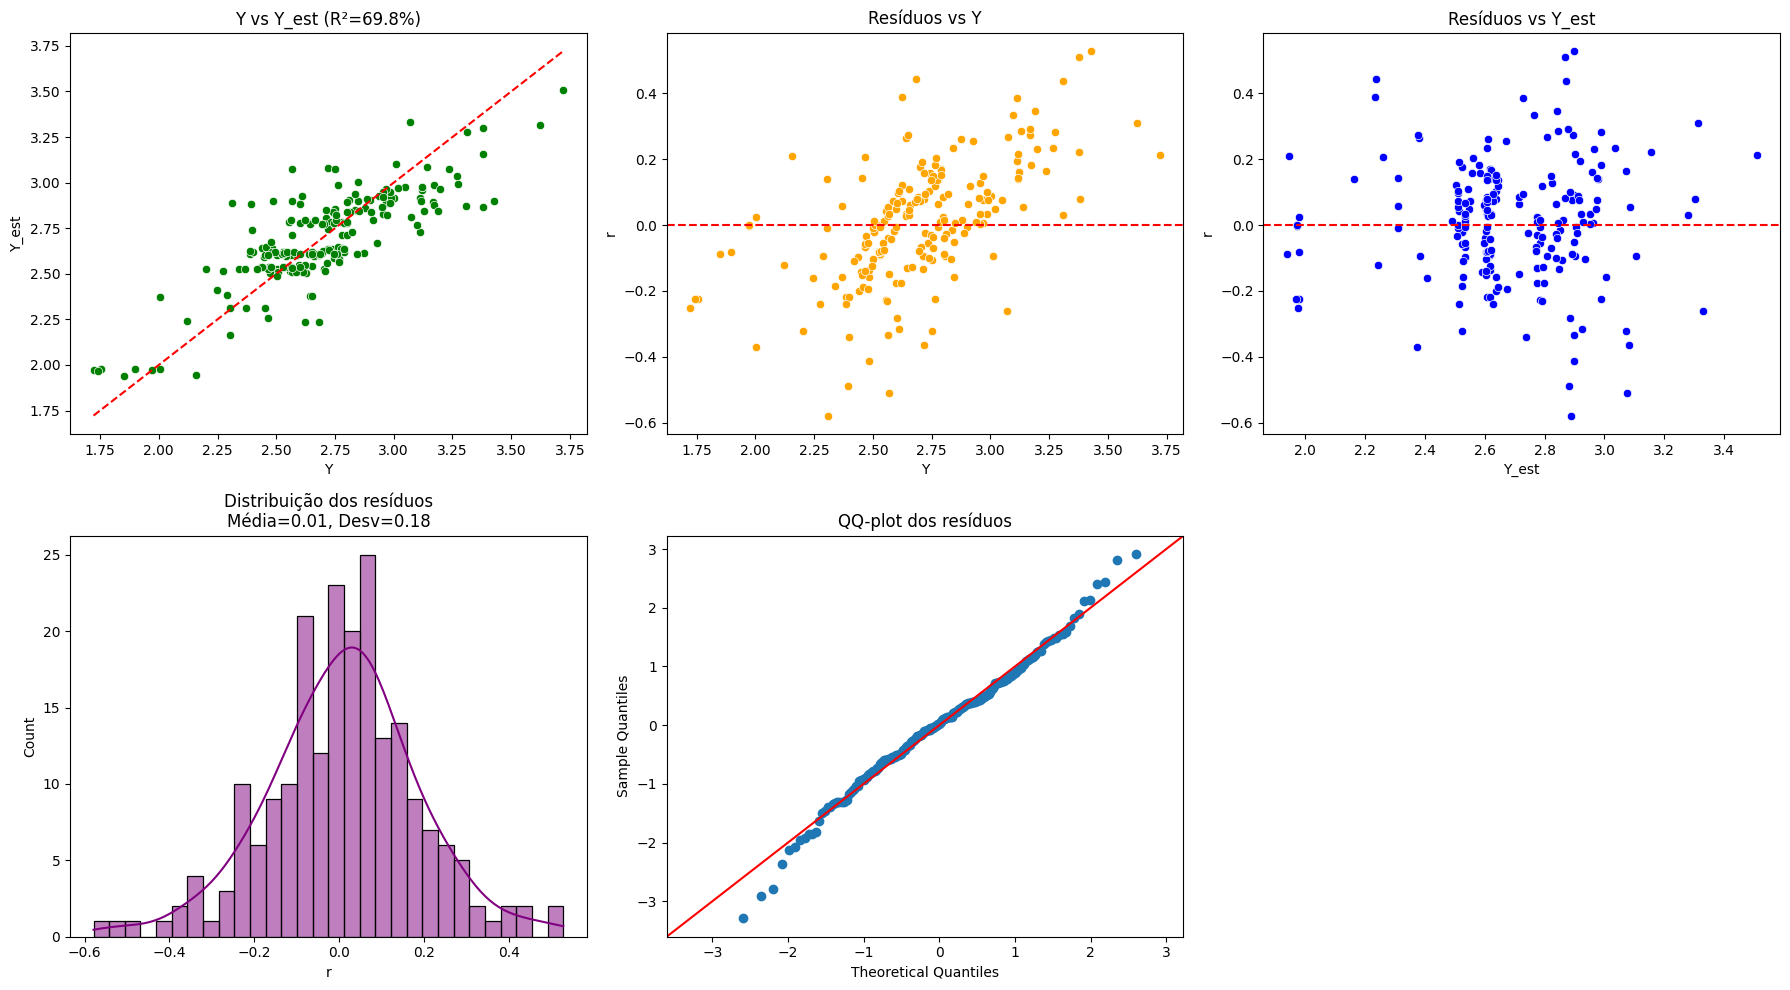

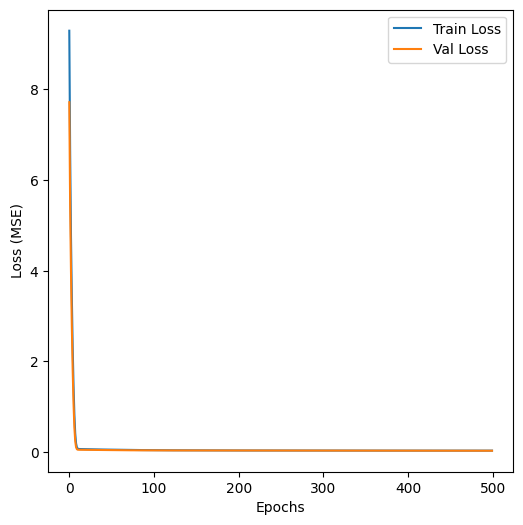

In [ ]:
y_pred = best_model['model'].predict(X_val).flatten()
plot_regression_diagnostics(y_val, y_pred)
history = best_model['history']
# plot training history
plt.figure(figsize=(6, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [99]:
#gridsearch for a linear regression model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
param_grid = {
    'fit_intercept': [True, False],
    'tol': [1e-4, 1e-3, 1e-2],
}
reg = LinearRegression()
grid_search = GridSearchCV(reg, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_reg = grid_search.best_estimator_
y_pred_reg = best_reg.predict(X_test)


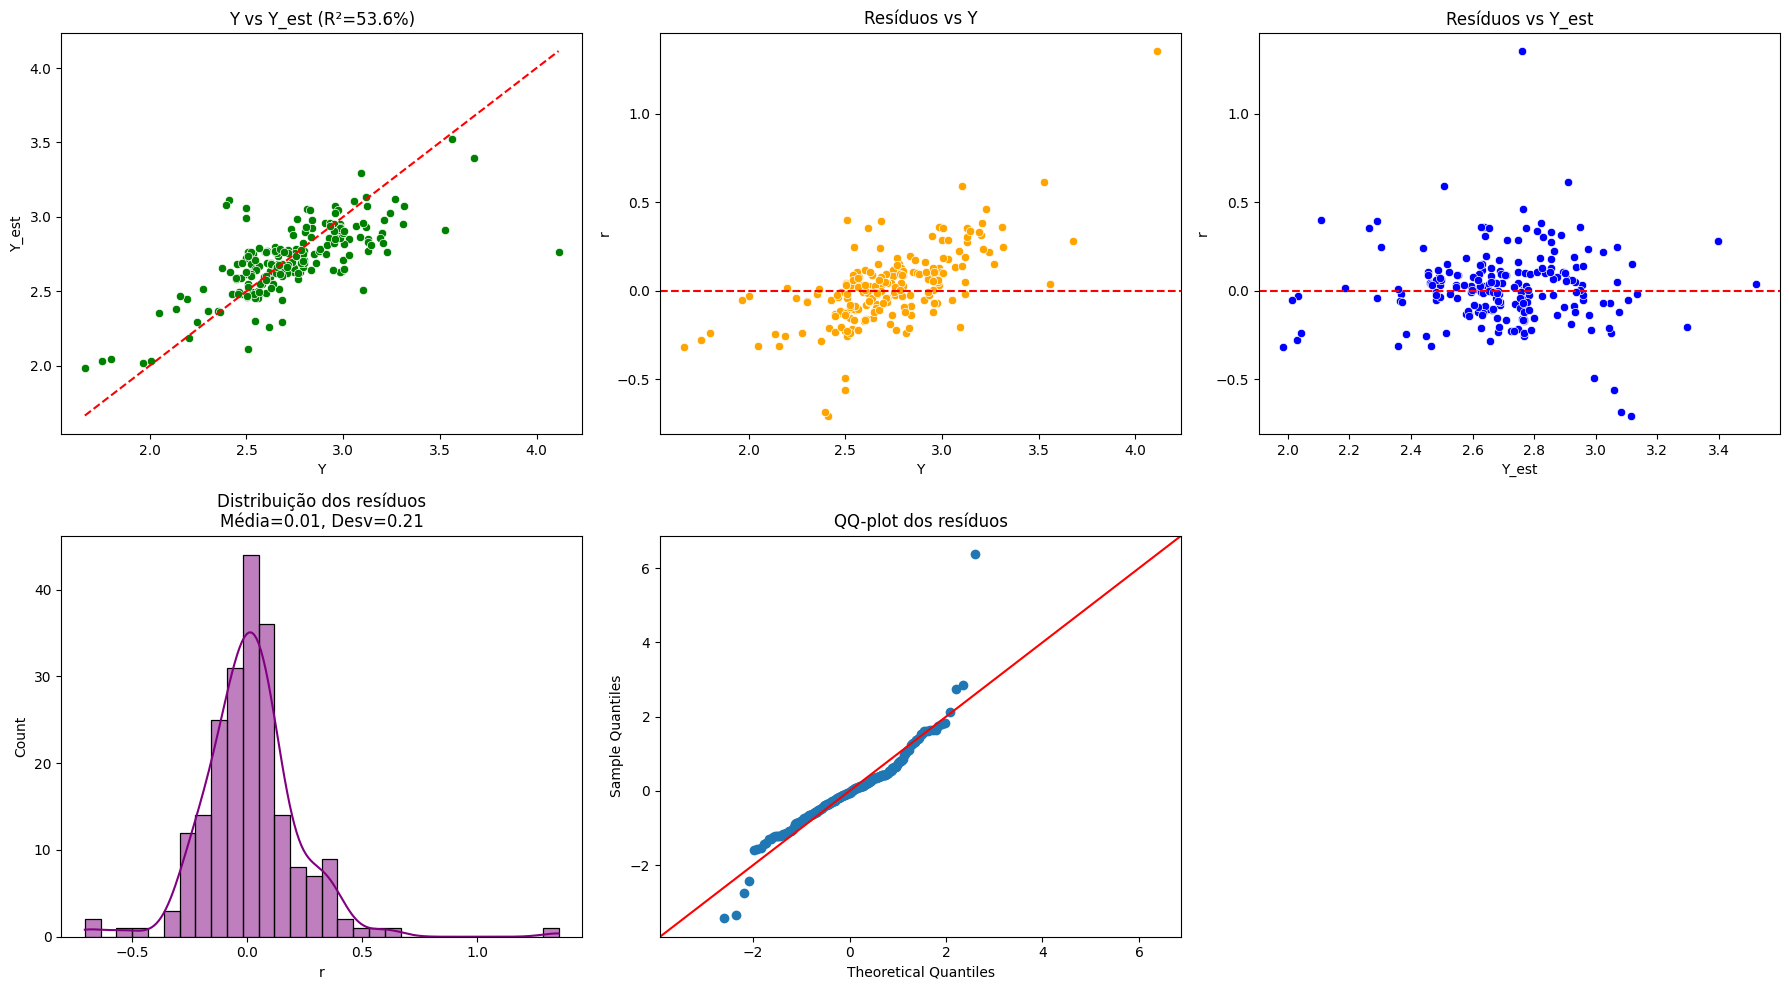

In [100]:
#plot r2, kde and residual of linear regression with r2 of best model
plot_regression_diagnostics(y_test, y_pred_reg)


In [101]:
lm_model, lm_X_val, lm_y_val = linear_model(X, y, random_seed, callbacks=[val_loss_stopping], adam_initial_lr=adam_initial_lr, adam_lr_decay=adam_lr_decay)
lm_y_pred = lm_model['model'].predict(X_test).flatten()


=== Ativação: linear ===
Treinamento fold 1


/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/leo/.pyenv/versions/reg-nn/lib/python3.13/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


[linear] Fold 1 - Val Loss: 6.1855, Val MSE: 6.1855
*** NOVO MELHOR MODELO! Activation: linear, Fold: 1, Val Loss: 6.1855 ***
Treinamento fold 2
[linear] Fold 2 - Val Loss: 3.2752, Val MSE: 3.2752
*** NOVO MELHOR MODELO! Activation: linear, Fold: 2, Val Loss: 3.2752 ***
Treinamento fold 3
[linear] Fold 3 - Val Loss: 59.3346, Val MSE: 59.3346
Treinamento fold 4
[linear] Fold 4 - Val Loss: 16.2162, Val MSE: 16.2162
Treinamento fold 5
[linear] Fold 5 - Val Loss: 36.6153, Val MSE: 36.6153
=== linear - Média Val Loss: 24.3253 ===

Melhor ativação: linear (fold 2) com val_loss=3.2752
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


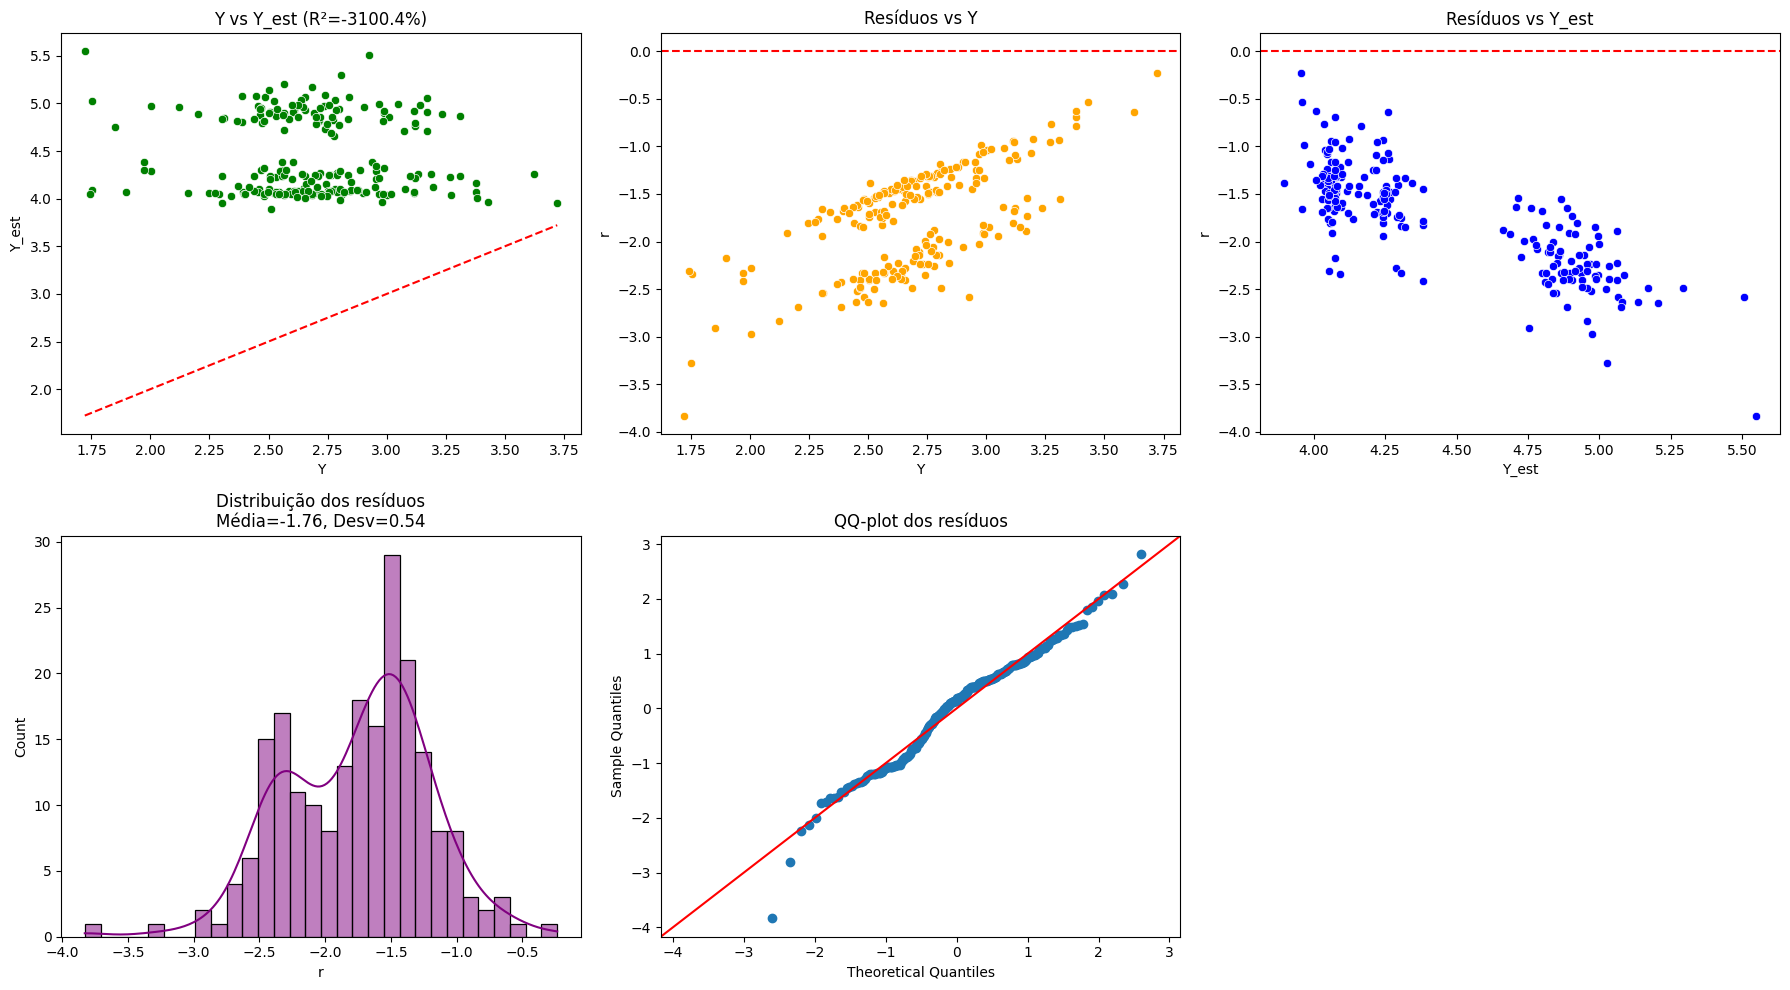

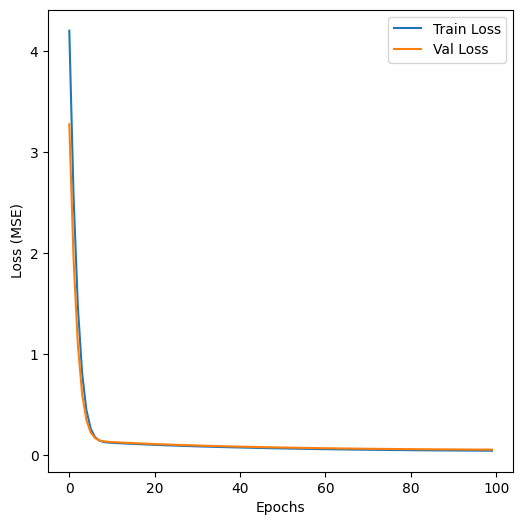

In [102]:
plot_regression_diagnostics(lm_y_val, lm_y_pred, X_val=lm_X_val)
history = lm_model['history']
# plot training history
plt.figure(figsize=(6, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()